# Telecom Customer Intelligence & Churn Analytics

## Objective

This project analyzes telecom customer behavior to understand churn drivers,
identify high-value customers at risk, and generate actionable retention insights.

### Key Areas

- Customer profile
- Service and network experience
- Usage behavior
- Complaints and support interactions
- Payment behavior
- Customer value
- Churn patterns
- Retention opportunities

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd
import os

print(os.listdir("../data"))


['processed', 'raw']


In [4]:
print(os.listdir("../data/raw"))


[]


In [5]:
print(os.listdir("../data/processed"))


[]


In [6]:
import os

for root, dirs, files in os.walk(".."):
    for file in files:
        print(os.path.join(root, file))

..\.gitignore
..\README.md
..\requirements.txt
..\.git\COMMIT_EDITMSG
..\.git\config
..\.git\description
..\.git\HEAD
..\.git\index
..\.git\hooks\applypatch-msg.sample
..\.git\hooks\commit-msg.sample
..\.git\hooks\fsmonitor-watchman.sample
..\.git\hooks\post-update.sample
..\.git\hooks\pre-applypatch.sample
..\.git\hooks\pre-commit.sample
..\.git\hooks\pre-merge-commit.sample
..\.git\hooks\pre-push.sample
..\.git\hooks\pre-rebase.sample
..\.git\hooks\pre-receive.sample
..\.git\hooks\prepare-commit-msg.sample
..\.git\hooks\push-to-checkout.sample
..\.git\hooks\sendemail-validate.sample
..\.git\hooks\update.sample
..\.git\info\exclude
..\.git\logs\HEAD
..\.git\logs\refs\heads\main
..\.git\logs\refs\remotes\origin\main
..\.git\objects\21\d4b78daab8ccbb71778aef8e4e6d42e94cda51
..\.git\objects\26\388258dd5582ff6feedca65bfc9bb336a90ae3
..\.git\objects\2e\55c2589c5e45bcef89d18bc40c0107b5410180
..\.git\objects\46\2c59413f028247c2aba637a80dd06d42308e2e
..\.git\objects\4b\825dc642cb6eb9a060e54bf

In [7]:
import os

print(os.listdir("../data/raw"))


['Telco_customer_churn.xlsx']


In [8]:
df = pd.read_excel("../data/raw/Telco_customer_churn.xlsx")

df.head()


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [9]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Rows: 7043
Columns: 33


In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [11]:
df = pd.read_excel("../data/raw/Telco_customer_churn.xlsx")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [12]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 7043
Number of columns: 33

Column names:
['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


In [13]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [14]:
df.isnull().sum().sort_values(ascending=False)

Churn Reason         5174
CustomerID              0
Count                   0
State                   0
Country                 0
Zip Code                0
Lat Long                0
Latitude                0
City                    0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Longitude               0
Internet Service        0
Online Security         0
Device Protection       0
Online Backup           0
Streaming TV            0
Streaming Movies        0
Contract                0
Tech Support            0
Paperless Billing       0
Payment Method          0
Total Charges           0
Monthly Charges         0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
dtype: int64

## Missing Value Observation

The `Churn Reason` column contains 5,174 missing values, while all other columns have no missing values.

This is expected because `Churn Reason` is only applicable to customers who have churned. Customers who have not churned do not have a churn reason recorded.

Therefore, these missing values should not be treated as a data quality issue at this stage.

In [15]:
pd.crosstab(
    df["Churn Label"],
    df["Churn Reason"].isna(),
    margins=True
)

Churn Reason,False,True,All
Churn Label,,,
No,0,5174,5174
Yes,1869,0,1869
All,1869,5174,7043


## Churn Reason Missing Value Validation

The `Churn Reason` column contains 5,174 missing values.

Cross-tabulation confirms that all missing values belong to customers who did not churn, while all 1,869 churned customers have a recorded churn reason.

Therefore, the missing values in `Churn Reason` are expected and represent a non-applicable value rather than missing data.

In [16]:
churn_counts = df["Churn Label"].value_counts()

print(churn_counts)


Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


In [17]:
churn_percentage = df["Churn Label"].value_counts(normalize=True) * 100

print(churn_percentage.round(2))

Churn Label
No     73.46
Yes    26.54
Name: proportion, dtype: float64


## Churn Distribution

The dataset contains 7,043 customers, of which 1,869 customers have churned and 5,174 customers have remained active.

The overall churn rate is 26.54%, while 73.46% of customers have not churned.

This indicates that approximately one in four customers in the dataset has churned, making customer retention an important business area for further analysis.

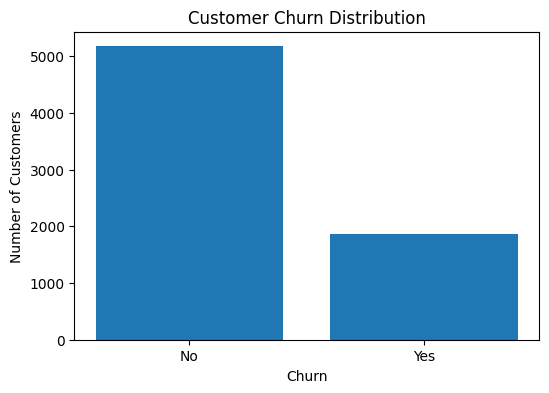

In [18]:
import matplotlib.pyplot as plt

churn_counts = df["Churn Label"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(churn_counts.index, churn_counts.values)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [19]:
pd.crosstab(
    df["Contract"],
    df["Churn Label"],
    normalize="index"
).round(3) * 100


Churn Label,No,Yes
Contract,,
Month-to-month,57.3,42.7
One year,88.7,11.3
Two year,97.2,2.8


## Contract Type vs Churn

Contract type shows a strong relationship with customer churn.

- Month-to-month customers have the highest churn rate at 42.7%.
- One-year contract customers have a churn rate of 11.3%.
- Two-year contract customers have the lowest churn rate at only 2.8%.

The analysis indicates that customers with longer-term contracts are substantially less likely to churn than month-to-month customers.

This suggests that contract type should be considered an important factor when developing customer retention strategies. However, this analysis identifies an association and does not establish causation.

In [20]:
df["Tenure Months"].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: Tenure Months, dtype: float64

In [21]:
bins = [0, 12, 24, 36, 48, 60, 72]
labels = ["0-12", "13-24", "25-36", "37-48", "49-60", "61-72"]

df["Tenure Group"] = pd.cut(
    df["Tenure Months"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

tenure_churn = pd.crosstab(
    df["Tenure Group"],
    df["Churn Label"],
    normalize="index"
).round(3) * 100

tenure_churn

Churn Label,No,Yes
Tenure Group,,
0-12,52.6,47.4
13-24,71.3,28.7
25-36,78.4,21.6
37-48,81.0,19.0
49-60,85.6,14.4
61-72,93.4,6.6


## Tenure vs Churn

Customer tenure shows a strong relationship with churn.

Customers with 0–12 months of tenure have the highest churn rate at 47.4%. The churn rate decreases consistently across higher tenure groups, reaching only 6.6% among customers with 61–72 months of tenure.

This indicates that newly acquired customers represent the highest-risk segment for churn. Retention efforts should therefore focus particularly on customers during their first year.

The analysis identifies an association between longer tenure and lower churn, but it does not establish a causal relationship.

In [22]:
df["Internet Service"].unique()


array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [23]:
df["Internet Service"].value_counts()


Internet Service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [24]:
internet_churn = pd.crosstab(
    df["Internet Service"],
    df["Churn Label"],
    normalize="index"
) * 100

internet_churn.round(2)

Churn Label,No,Yes
Internet Service,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


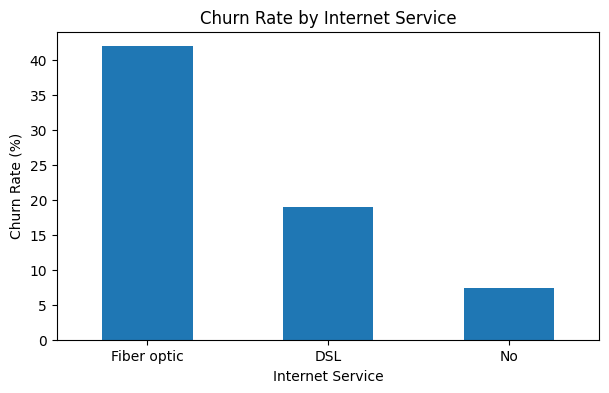

In [25]:
internet_churn["Yes"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [26]:
internet_churn


Churn Label,No,Yes
Internet Service,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980
